# ViT CRP Walkthrough

Concept attribution + relevance maximisation on ViTs via unfolded attention. Default model: **DINOv3-pretrained ViT-B/16 + public ImageNet-1k linear head** (`vit_dinov3_base_imagenet` in the model zoo — the same off-the-shelf checkpoint the CRP gallery uses). Everything auto-downloads; no local training needed. Three concepts — `HeadConcept`, `EmbeddingDimConcept`, `TokenConcept` — hookable at `q_lrp_probe` / `k_lrp_probe` / `v_lrp_probe` / `proj_drop`.

## Setup

1. `uv sync` — the IDE picks up the repo `.venv` as the notebook kernel.
2. Run top to bottom. Backbone, head and dataset auto-download on first use.

## Where things are defined

This notebook prints the live registries at runtime instead of hardcoding option lists — add a model / dataset / composite in the places below and it shows up here without editing the notebook:

* **Models** — one class per journal model in [`experiments/models/zoo.py`](../../experiments/models/zoo.py) (`MODELS` registry); bases/heads/probe composition in [`experiments/models/`](../../experiments/models/__init__.py).
* **Datasets** — loader registry, experiment keys (`EVAL_DATASETS`) and `load_eval_dataset` in [`experiments/datasets/`](../../experiments/datasets/__init__.py).
* **LRP composites** — one file per source paper in [`zennit_extensions/lrp_composites/`](../../zennit_extensions/lrp_composites/), with the name → class registry `COMPOSITES` right there.

Training your own probe / running the gallery from the shell: `uv run python -m experiments.train_probe --help` · `uv run python -m experiments.crp_gallery --help`.

Hardware: ViT-B/16 @ 256 px wants a GPU with ≥8 GB VRAM; CPU works but the FV index (section 5) will be slow.

## Structure
1 setup · 2 config + composite · 3 hookable layers (+ graph/sanity) · 4 dataset + focal image · 5 FV index · 6 reference samples · 7 conditional cascade · 8 notes

## 1. Setup

In [2]:
%matplotlib inline
from __future__ import annotations
from pathlib import Path

# Walk up from the notebook's location to find the repo root — only used to
# point at <repo>/data/. No sys.path manipulation: `experiments` and `crp` are
# installable packages exposed by `uv sync`.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').is_file():
    REPO_ROOT = REPO_ROOT.parent

import torch
import numpy as np
import matplotlib.pyplot as plt

from crp.attribution import CondAttribution
from crp.concepts import HeadConcept, EmbeddingDimConcept, TokenConcept
from crp.visualization import FeatureVisualization
from crp.helper import get_layer_names
from crp.image import plot_grid

from zennit_extensions import LRPInspectionLayer
from zennit_extensions.lrp_composites import COMPOSITES
from experiments.models import MODELS, backbone_transforms
from experiments.datasets import EVAL_DATASETS, load_eval_dataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}')

# The registries are the single source of truth — print them, never hardcode:
print(f'models     : {sorted(MODELS)}   (experiments/models/zoo.py)')
print(f'datasets   : {sorted(EVAL_DATASETS)}   (experiments/datasets/)')
print(f'available composites : {sorted(COMPOSITES)}   (zennit_extensions/lrp_composites/)')

device: cuda
models     : ['vit_base_imagenet', 'vit_dinov3_base_imagenet', 'vit_dinov3_small_funny_birds', 'vit_small_colored_mnist', 'vit_small_dsprites', 'vit_small_funny_birds']   (experiments/models/zoo.py)
datasets   : ['colored_mnist', 'dsprites', 'funny_birds', 'imagenet']   (experiments/datasets/)
available composites : ['attnlrp_baseline', 'chefer_lrp', 'cp_lrp_baseline']   (zennit_extensions/lrp_composites/)


## 2. Configuration — model + composite

One class per journal model in `experiments/models/zoo.py`: the architecture is encoded in the class, the only parameters are where the weights come from — off-the-shelf models download themselves, finetuned probes accept `checkpoint=<best.pt>` to pin an exact run (default: newest under `data/runs/`). Default here: **`vit_dinov3_base_imagenet`** — DINOv3-pretrained ViT-B/16 + the public canvit ImageNet-1k linear head on the frozen cls token.

`DATASET` must be the matching eval-dataset key from `EVAL_DATASETS`. Training new probes: `uv run python -m experiments.train_probe --help`; gallery CLI: `uv run python -m experiments.crp_gallery --help`.

In [73]:
# === MODEL CHOICE ===
MODEL_KEY = 'vit_base_imagenet'   # key of MODELS (printed above)
DATASET   = 'imagenet'                   # matching EVAL_DATASETS key

# Finetuned-probe classes accept checkpoint=<path> to pin an exact run.
model = MODELS[MODEL_KEY](device=DEVICE)
print(f'model  : {MODEL_KEY}  ({model.num_classes} classes, head {model.head_name})')
print(f'weights: {model.source}')

RANDOM_SEED = 0

print(model)


model  : vit_base_imagenet  (1000 classes, head timm_builtin)
weights: timm:vit_base_patch16_224
ImagenetViTBase(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)


In [74]:
# Un-normalized-dataset + normalize-at-forward split (single source of truth:
# experiments/models/transforms.py). The dataset yields display-ready [0, 1]
# tensors; `normalize` is applied at the forward boundary so the model sees its
# expected input distribution.
transform, normalize = backbone_transforms(model.backbone)

backbone   = model.backbone
NUM_BLOCKS = len(backbone.blocks)
NUM_HEADS  = int(backbone.blocks[0].attn.num_heads)
EMBED_DIM  = int(backbone.embed_dim)
HEAD_DIM   = int(getattr(backbone.blocks[0].attn, 'head_dim', EMBED_DIM // NUM_HEADS))
NUM_PREFIX_TOKENS = int(getattr(backbone, 'num_prefix_tokens', 1))
NUM_PATCHES = int(backbone.patch_embed.num_patches)
IMAGE_SIZE = (int(backbone.patch_embed.img_size[0]), int(backbone.patch_embed.img_size[1]))

print(f'blocks     : {NUM_BLOCKS}')
print(f'embed_dim  : {EMBED_DIM}')
print(f'num_heads  : {NUM_HEADS}  (head_dim {HEAD_DIM})')
print(f'patches    : {NUM_PATCHES}')
print(f'num_prefix : {NUM_PREFIX_TOKENS}')
print(f'image_size : {IMAGE_SIZE}  (patch size {backbone.patch_embed.patch_size})')



blocks     : 12
embed_dim  : 768
num_heads  : 12  (head_dim 64)
patches    : 196
num_prefix : 1
image_size : (224, 224)  (patch size (16, 16))


## 4. Load dataset + focal image

`load_eval_dataset` resolves the experiment key through `EVAL_DATASETS` to the loader registry, all in `experiments/datasets/` — auto download/extract, un-normalized transform convention. Split/variant kwargs go through its `extra_kwargs` parameter (see the loader signatures in `experiments/datasets/`). Focal image = first correctly-classified sample; attribution targets its predicted class.

In [75]:
# ImageNet always constructs the FULL 50k val split; for an interactive
# walkthrough subsample a per-class pool AFTER construction (deterministic,
# seed=0). Drop the subsample line to index the full split in section 5 —
# that is what the gallery does.
dataset = load_eval_dataset(DATASET, transform)
if DATASET == 'imagenet':
    dataset.subsample(5)   # 5 per class → 5000 imgs
dataset_eval = dataset
print(f'dataset ({DATASET}): {len(dataset)} imgs, {dataset.num_classes} classes')

  loading ImageNet-1k val from HF mirror (cache: /home/claude/workspaces/zennit-crp/data/imagenet_val_hf/cache)
  reading val-00000-of-00002-b5248be478d25e41.parquet
  reading val-00001-of-00002-85f3d9c8fa1edb63.parquet
  total: 50000 samples, 1000 classes
dataset (imagenet): 5000 imgs, 1000 classes


### Pick the focal image

focal image: dataset index 432, class 645
predicted class name: maypole
original class name: maypole


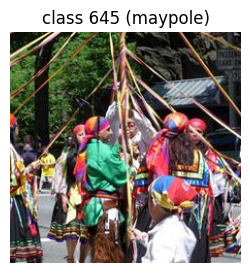

In [79]:
from timm.data import ImageNetInfo

IN1K_INFO = ImageNetInfo()

stride = max(1, len(dataset) // 30)
focal_image = focal_class = focal_index = None
for i in range(100, len(dataset), stride):
    x_, y_ = dataset[i]
    x_dev = x_.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = model(normalize(x_dev)).argmax(-1).item()
    if pred == int(y_):
        focal_image = x_dev.detach().requires_grad_(True)
        focal_class = pred
        focal_index = i
        break
if focal_image is None:
    raise RuntimeError(
        f'No correctly-classified sample found in first {len(dataset)//stride} '
        f'strided samples — check model/dataset compatibility.'
    )

print(f'focal image: dataset index {focal_index}, class {focal_class}')
predicted_class_name = IN1K_INFO.index_to_description(focal_class)
original_class_name = IN1K_INFO.index_to_description(int(dataset[focal_index][1]))
print(f'predicted class name: {predicted_class_name}')
print(f'original class name: {original_class_name}')

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(focal_image[0].detach().cpu().permute(1, 2, 0).numpy()); ax.axis('off')
ax.set_title(f'class {focal_class} ({predicted_class_name})')
plt.show()

### Sanity-eval: does the model classify this dataset?

Run the model on a slice of `dataset_eval`. Near-chance = model loaded wrong (head shape / transform mismatch). Bump `EVAL_SUBSET_SIZE` for a tighter estimate.

In [77]:
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

EVAL_SUBSET_SIZE = 800  # sanity-eval sample count (section 4)
n_eval = min(EVAL_SUBSET_SIZE, len(dataset_eval))
_loader = DataLoader(
    Subset(dataset_eval, list(range(n_eval))),
    batch_size=32, shuffle=True, num_workers=2,
)
_correct = _total = 0
with torch.no_grad():
    for _x, _y in tqdm(_loader, desc='sanity-eval', unit='batch'):
        # Dataset yields unnormalized tensors; normalize at the forward
        # boundary.
        _logits = model(normalize(_x.to(DEVICE)))
        _correct += (_logits.argmax(-1).cpu() == _y).sum().item()
        _total   += _y.numel()
print(f'Sanity-eval top-1 over {_total} samples of dataset_eval: {_correct/_total:.4f}')

sanity-eval:   0%|          | 0/25 [00:00<?, ?batch/s]

Sanity-eval top-1 over 800 samples of dataset_eval: 0.8375


### Composite

Define varying Composites to explore the paper variants and our own variants.
Use native Composite classes from zennit.
When you switch composite or kwargs, set `EXPERIMENT_TAG` (section 2) so section 5's FV cache stays separate.

In [80]:
import torch
import torch.nn as nn
from zennit.composites import Composite, LayerMapComposite, MixedComposite, NameMapComposite
from zennit.rules import Epsilon, Gamma, Pass
from zennit.composites import LayerMapComposite, MixedComposite
from zennit_extensions.canonisation.canonizers import EvaAttentionSubstitutionCanonizer, EvaBlockResidualCanonizer, FFNLinearSubstitutionCanonizer, VanillaViTAttentionSubstitutionCanonizer, VanillaViTBlockResidualCanonizer
from zennit.rules import Pass
from zennit_extensions.attention_unfolded import (
    BilinearMatmul,
    FFNLinear,
    LayerNormDetachedStd,
    LayerScaleMul,
    PosEmbedAdd,
    ResidualAdd,
    RotaryEmbedding,
    ScaleByConstant,
    SoftmaxAlongLastDim,
)
from zennit_extensions.canonisation.canonizers import (
    EvaAttentionSubstitutionCanonizer,
    EvaBlockResidualCanonizer,
    LayerNormSubstitutionCanonizer,
    VanillaViTAttentionSubstitutionCanonizer,
    VanillaViTBlockResidualCanonizer,
    VanillaViTPosEmbedCanonizer,
)
from zennit_extensions.rules.attnlrp import (
    EpsilonAdd,
    LayerNormEpsilon,
    MatmulAttnLRP,
    SoftmaxAttnLRP,
)
from zennit_extensions.rules.palrp import PosEmbedSink, RotaryRopeSink

# Optional suffix on the FV cache dir (section 5) — set a short identifier when
# running a composite variant whose reference samples must stay distinct from
# the baseline (e.g. 'gamma025'). Empty string → baseline path.
EXPERIMENT_TAG = 'attnlrp_default1'

composite = MixedComposite(
    composites=[
        # name-dispatched exceptions first — first match wins
        NameMapComposite(name_map=[
            (('head',), Gamma(gamma=0.01)),   # strict Table B.5: Linear outside attention → γ
        ]),
        # type-dispatched bulk of the recipe
        LayerMapComposite(layer_map=[
            (BilinearMatmul, MatmulAttnLRP(epsilon=1e-6)),                        # Eq. 15
            (SoftmaxAlongLastDim, SoftmaxAttnLRP(bias_mode="absorb")),            # Prop. 3.1
            (LayerNormDetachedStd, LayerNormEpsilon(epsilon=1e-6, bias_mode="absorb")),  # LXT LN
            (ResidualAdd, EpsilonAdd(epsilon=1e-6)),                              # LXT add2
            (LayerScaleMul, Pass()),          # bias-free elementwise linear ⇒ identity
            (ScaleByConstant, Pass()),
            (nn.GELU, Pass()),                # Eq. 9 elementwise identity
            (nn.LayerNorm, Pass()),           # fallback: subclasses the canonizer skips
            (nn.Dropout, Pass()),
            (FFNLinear, Gamma(gamma=0.01)),   # Table B.5 FFN-γ — MUST precede nn.Linear
            (nn.Linear, Epsilon(epsilon=1e-6)),  # qkv / proj → ε
            (nn.Conv2d, Gamma(gamma=0.25)),   # patch embed
            # (RotaryEmbedding, RotaryRopeSink()),  # PA-LRP RoPE sink (changes attributions + EXPERIMENT_TAG!)
            # (PosEmbedAdd, PosEmbedSink()),        # PA-LRP pos-embed sink, vanilla ViTs only
            (nn.Identity, Pass()),
        ]),
    ],
    canonizers=[
        VanillaViTBlockResidualCanonizer(),
        EvaBlockResidualCanonizer(layerscale_uniform=True),
        VanillaViTPosEmbedCanonizer(),
        EvaAttentionSubstitutionCanonizer(block_indices=None),
        VanillaViTAttentionSubstitutionCanonizer(block_indices=None),
        LayerNormSubstitutionCanonizer(),     # nn.LayerNorm → LayerNormDetachedStd
        FFNLinearSubstitutionCanonizer(),     # MLP nn.Linear → FFNLinear marker
    ],
)



attribution = CondAttribution(model)

Sanity checking that the unfolding of the model does not change the output: `model(x).argmax(-1) == unfolded_model(x).argmax(-1)`.

Deliberately performed in float64 to avoid any FP32/FP16 differences caused by the float operation order changing when unfolding the model.

In [81]:
def _check_float64_parity(model, composite, x):
    import copy, gc, torch

    m64 = copy.deepcopy(model).double().eval()
    x64 = x.double()
    try:
        with torch.no_grad():
            ref64 = m64(x64)
        with composite.context(m64):
            with torch.no_grad():
                out64 = m64(x64)
        d = (out64 - ref64).abs().max().item()
        print(f"float64 max|Δ| = {d:.3e}")
        assert d < 1e-9, "REAL parity violation — not float noise, investigate"
        print("Unfolded model output matches original model output in float64.")
    finally:
        del m64, x64
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

x = torch.rand(1, 3, 224, 224).to(DEVICE)
_check_float64_parity(model, composite, x)
del _check_float64_parity


float64 max|Δ| = 1.199e-14
Unfolded model output matches original model output in float64.


## 3. Hookable layers

Unfolded attention exposes multiple `LRPInspectionLayer` sites/block — `q_lrp_probe` / `k_lrp_probe` / `v_lrp_probe` (post qkv-split, pre head-reshape). All carry `(B, N, embed_dim)`, same as `proj_drop`.
Concepts act on that shape:

| Concept | Selects | Sites |
|---|---|---|
| `HeadConcept(num_heads)` | one head's embed_dim slice (sums head_dim) | q/k/v_lrp_probe, proj_drop |
| `EmbeddingDimConcept(num_heads)` | one embed_dim index | same |
| `TokenConcept()` | one token position | proj_drop |

Optional `TokenConcept(token_filter=slice(...))` restricts tokens (`slice(num_prefix_tokens, None)` = spatial only; default = all).
List sites: `get_layer_names(model, [LRPInspectionLayer])`; `proj_drop` / `context` via `model.named_modules()`.

In [83]:
# Enumerate all LRPInspectionLayer sites in the model. Three per
# block: q_lrp_probe / k_lrp_probe / v_lrp_probe.
from torch.nn import Linear

from zennit_extensions.attention_unfolded import KInspectionLayer, QInspectionLayer, RotaryEmbedding, VInspectionLayer


with composite.context(model):
    # probe_layer_names = get_layer_names(model, [LRPInspectionLayer])
    probe_layer_names = get_layer_names(model, [QInspectionLayer, KInspectionLayer, VInspectionLayer])
    # probe_layer_names = get_layer_names(model, [RotaryEmbedding])
            

print(f'Matched sites: {len(probe_layer_names)} total')
for n in probe_layer_names:
    print(f'  {n}')


Matched sites: 36 total
  backbone.blocks.0.attn.q_lrp_probe
  backbone.blocks.0.attn.k_lrp_probe
  backbone.blocks.0.attn.v_lrp_probe
  backbone.blocks.1.attn.q_lrp_probe
  backbone.blocks.1.attn.k_lrp_probe
  backbone.blocks.1.attn.v_lrp_probe
  backbone.blocks.2.attn.q_lrp_probe
  backbone.blocks.2.attn.k_lrp_probe
  backbone.blocks.2.attn.v_lrp_probe
  backbone.blocks.3.attn.q_lrp_probe
  backbone.blocks.3.attn.k_lrp_probe
  backbone.blocks.3.attn.v_lrp_probe
  backbone.blocks.4.attn.q_lrp_probe
  backbone.blocks.4.attn.k_lrp_probe
  backbone.blocks.4.attn.v_lrp_probe
  backbone.blocks.5.attn.q_lrp_probe
  backbone.blocks.5.attn.k_lrp_probe
  backbone.blocks.5.attn.v_lrp_probe
  backbone.blocks.6.attn.q_lrp_probe
  backbone.blocks.6.attn.k_lrp_probe
  backbone.blocks.6.attn.v_lrp_probe
  backbone.blocks.7.attn.q_lrp_probe
  backbone.blocks.7.attn.k_lrp_probe
  backbone.blocks.7.attn.v_lrp_probe
  backbone.blocks.8.attn.q_lrp_probe
  backbone.blocks.8.attn.k_lrp_probe
  backbone.blo

### Single-block computation graph

Render one unfolded attention block as a graph. Composite context swaps stock attention → `EvaAttentionUnfolded` / `TimmAttentionUnfolded`, exposing every op (`qkv`, `q/k/v_lrp_probe`, `scale_q`, `qk_scores`, `softmax`, `context`, `proj`, …) as a named child. Names = the strings for `record_layer=[...]` / condition dicts.
Via [`torchview`](https://github.com/mert-kurttutan/torchview) + Graphviz (SVG); no graphviz → prints the submodule tree. Install: `apt install graphviz` / `brew install graphviz`.

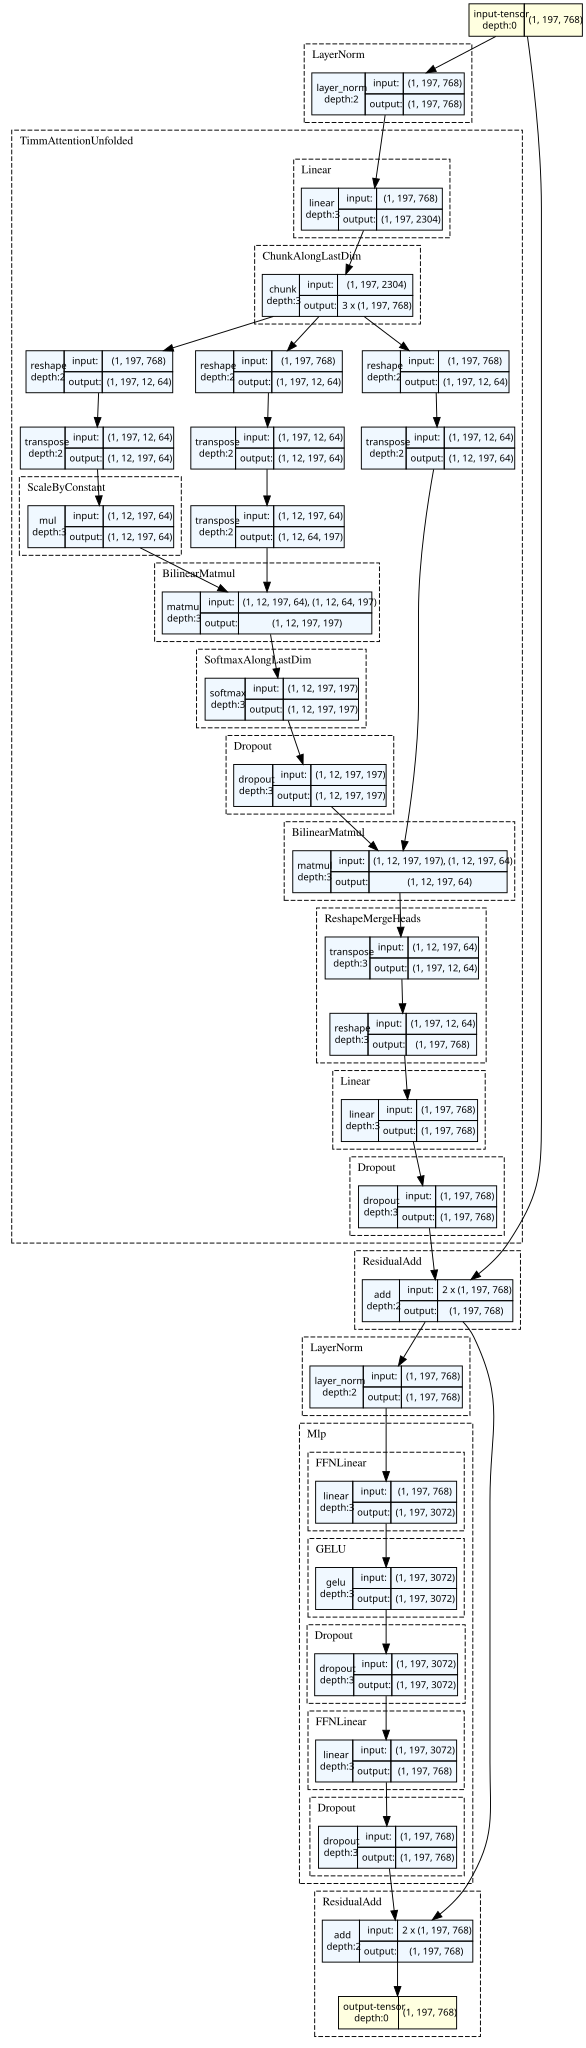

In [86]:
BLOCK_TO_VIZ = 0  # block index to render — same graph for all blocks

try:
    from torchview import draw_graph
    _can_torchview = True
except ImportError:
    print('torchview not installed; run `uv pip install torchview` and re-run.')
    _can_torchview = False

_N = NUM_PREFIX_TOKENS + NUM_PATCHES   # token-sequence length

if _can_torchview:
    # Substitute the attention with its unfolded variant via the composite
    # context — that's the graph we actually run attribution against.
    with composite.context(model) as modified:
        block = modified.backbone.blocks[BLOCK_TO_VIZ]

        if any(isinstance(m, RotaryEmbedding) for m in block.modules()):
        # steal the real rope tensor from one full forward
            grab = {}
            h = block.attn.rope_q.register_forward_pre_hook(lambda m, args: grab.update(rope=args[1]))
            with torch.no_grad():
                model(torch.randn(1, 3, *IMAGE_SIZE, device=DEVICE))
            h.remove()

        _x = torch.randn(1, _N, EMBED_DIM, device=DEVICE)
        try:
            g = draw_graph(
                block, input_data=(_x, grab['rope']) if grab else (_x,),  # (x, rope)
                depth=3, expand_nested=True,
                graph_name=f'block_{BLOCK_TO_VIZ}',
                hide_module_functions=False,
            )
            # Render to in-memory SVG. Requires system `graphviz` (the
            # `dot` binary). On a missing binary the call raises;
            # we catch and fall back to a structural print below.
            from IPython.display import display, SVG
            svg_str = g.visual_graph.pipe(format='svg').decode('utf-8')
            display(SVG(svg_str))
        except Exception as e:
            print(f'graphviz render failed ({type(e).__name__}: {e!s}).')
            print(f'Falling back to named-submodule tree of block {BLOCK_TO_VIZ}:')
            print('  ' + '\n  '.join(
                f'{name}: {type(m).__name__}'
                for name, m in block.named_modules() if name
            ))

#### Canonized-block sanity check

torchview dead-ends = layout artifact, not real. Ground truth:
1. **Forward parity** — unfolded block output == stock block output (fp32 noise).
2. **No dead ends** — every named submodule output has nonzero grad w.r.t. block output. Zero/`None` grad = real bug.

In [87]:
# ── all-blocks sanity: forward parity + dead-end check per block ───────────
import torch as _torch_chk


def _check_all_blocks(model, composite):
    x = _torch_chk.randn(1, _N, EMBED_DIM, device=DEVICE)

    # stock reference for every block, before canonization
    with _torch_chk.no_grad():
        y_stock = [blk(x) for blk in model.backbone.blocks]

    n_mismatch = n_dead_total = 0
    with composite.context(model) as modified:
        for i, blk in enumerate(modified.backbone.blocks):
            # 1. forward parity
            with _torch_chk.no_grad():
                y_sub = blk(x)
            max_diff = (y_sub - y_stock[i]).abs().max().item()
            ok = max_diff < 1e-2 * max(abs(y_stock[i].sum().item()), 1.0)
            n_mismatch += not ok

            # 2. dead-end check
            captured, handles = {}, []
            for name, m in blk.named_modules():
                if not name:
                    continue
                def _hook(mod, inp, out, __n=name, __c=captured):
                    if isinstance(out, _torch_chk.Tensor) and out.requires_grad:
                        out.retain_grad()
                        __c[__n] = out
                handles.append(m.register_forward_hook(_hook))
            try:
                blk(x.clone().requires_grad_()).sum().backward()
            finally:
                for h in handles:
                    h.remove()
            dead = [n for n, t in captured.items()
                    if t.grad is None or t.grad.abs().sum().item() == 0]
            n_dead_total += len(dead)

            line = (f'block {i:2d}: fwd Δmax={max_diff:.3e} '
                    f'[{"OK" if ok else "MISMATCH"}]  '
                    f'{len(captured)} submodules, {len(dead)} dead')
            print(line)
            for n in dead:
                print(f'      dead: {n}')

    print(f'\nsummary: {n_mismatch} forward mismatch(es), '
          f'{n_dead_total} dead end(s) across {len(y_stock)} blocks')


_check_all_blocks(model, composite)
del _check_all_blocks


block  0: fwd Δmax=9.537e-06 [OK]  32 submodules, 0 dead
block  1: fwd Δmax=5.245e-06 [OK]  32 submodules, 0 dead
block  2: fwd Δmax=2.623e-06 [OK]  32 submodules, 0 dead
block  3: fwd Δmax=1.907e-06 [OK]  32 submodules, 0 dead
block  4: fwd Δmax=1.192e-06 [OK]  32 submodules, 0 dead
block  5: fwd Δmax=9.537e-07 [OK]  32 submodules, 0 dead
block  6: fwd Δmax=9.537e-07 [OK]  32 submodules, 0 dead
block  7: fwd Δmax=2.861e-06 [OK]  32 submodules, 0 dead
block  8: fwd Δmax=7.629e-06 [OK]  32 submodules, 0 dead
block  9: fwd Δmax=4.053e-06 [OK]  32 submodules, 0 dead
block 10: fwd Δmax=2.670e-05 [OK]  32 submodules, 0 dead
block 11: fwd Δmax=1.717e-05 [OK]  32 submodules, 0 dead

summary: 0 forward mismatch(es), 0 dead end(s) across 12 blocks


### Plain attribution (no concept conditioning) for reference

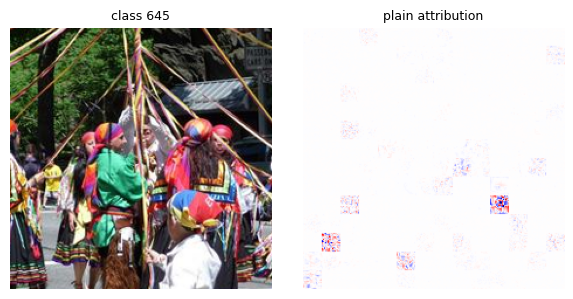

In [88]:
from zennit_extensions.attention_unfolded import PosEmbedAdd, RotaryEmbedding

# ── plain attribution (unchanged) ───────────────────────────────────────────
x_run = normalize(focal_image).detach().clone().requires_grad_(True)
res = attribution(x_run, [{'y': [focal_class]}], composite)
heatmap = res.heatmap[0].detach().cpu().numpy()

# ── positional sinks: manual pass inside the context (CondAttribution
#    closes its own context, which wipes the per-backward sink stashes) ─────
def _positional_maps(model, composite, x_norm, target, grid_hw):
    """PA-LRP Eq. 11 per-mechanism positional maps: relu → sum feature dims →
    drop prefix tokens → patch grid; RoPE sinks summed over blocks & q/k."""
    maps = {}
    x = x_norm.detach().clone().requires_grad_(True)
    with composite.context(model):
        model(x)[0, target].backward()
        for name, m in model.named_modules():
            if not isinstance(m, (PosEmbedAdd, RotaryEmbedding)):
                continue
            sink = getattr(m, '_palrp_sink', None)
            if sink is None:
                continue
            pos = sink[0].relu()                                  # (·)+, Eq. 11
            dims = tuple(d for d in range(pos.dim()) if d != pos.dim() - 2)
            per_token = pos.sum(dim=dims)                         # per token
            per_token = per_token[-grid_hw[0] * grid_hw[1]:]      # drop cls/reg
            key = 'rope' if isinstance(m, RotaryEmbedding) else 'pos_embed'
            maps[key] = maps.get(key, 0) + per_token.reshape(grid_hw).cpu().numpy()
    return maps

_grid = (int(NUM_PATCHES ** 0.5),) * 2
pos_maps = _positional_maps(model, composite, normalize(focal_image), focal_class, _grid)

# ── plot: image | plain heatmap | one panel per positional mechanism ───────
_panels = 2 + len(pos_maps)
fig, axes = plt.subplots(1, _panels, figsize=(3 * _panels, 3))
axes[0].imshow(focal_image[0].detach().cpu().permute(1, 2, 0).numpy())
axes[0].set_title(f'class {focal_class}', fontsize=9)
vmax = abs(heatmap).max()
axes[1].imshow(heatmap, cmap='seismic', vmin=-vmax, vmax=vmax)
axes[1].set_title('plain attribution', fontsize=9)
for ax, (key, grid) in zip(axes[2:], sorted(pos_maps.items())):
    ax.imshow(grid, cmap='inferno')   # relu'd → one-sided colormap
    ax.set_title(f'positional: {key}', fontsize=9)
for ax in axes:
    ax.axis('off')
plt.tight_layout(); plt.show()


## 5. Build FV index

3 concepts × target sites (probes + `proj_drop`). FV indexes each concept id's relevance over the dataset, caches top-N images.

Cache (per model key, parallel-safe):

```
data/fv_cache/<model-key>[_<tag>]/<spec>/
    RelMax_*/   ActMax_*/    # top-N indices
```

Re-run safe: existing `<spec>/RelMax_*/*_data.npy` → skip indexing, rebind to disk. Force rebuild: delete the spec folder. (The gallery's own FV cache is separate — scratch + persistent mirror, see `experiments/storage.py`.)

In [12]:
# Cache root keyed by the model registry key — switching the section-2 choice
# routes to a different cache, so models don't collide.
# Independent caches are also safe across parallel notebook kernels.
# EXPERIMENT_TAG (section 2) suffixes the dir so composite variants can
# index in parallel without overwriting each other.
_suffix = f'_{EXPERIMENT_TAG}' if EXPERIMENT_TAG else ''
FV_CACHE_DIR = REPO_ROOT / 'data' / 'fv_cache' / f'{MODEL_KEY}{_suffix}'
FV_CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f'cache dir: {FV_CACHE_DIR.relative_to(REPO_ROOT)}')

# Quick defaults: index a single concept × single layer for each
# concept type. Comment / uncomment / extend per your analysis. Adding
# more layers per fv_specs entry just grows the layer_map of one
# FeatureVisualization — same one forward+backward pass per image.
_LAST_BLOCK = NUM_BLOCKS - 1
_MID_BLOCK  = NUM_BLOCKS // 2
_LAST_PROJ   = f'backbone.blocks.{_LAST_BLOCK}.attn.proj_drop'
_MID_PROJ    = f'backbone.blocks.{_MID_BLOCK}.attn.proj_drop'
_LAST_QPROBE = f'backbone.blocks.{_LAST_BLOCK}.attn.q_lrp_probe'
_LAST_KPROBE = f'backbone.blocks.{_LAST_BLOCK}.attn.k_lrp_probe'
_LAST_VPROBE = f'backbone.blocks.{_LAST_BLOCK}.attn.v_lrp_probe'

fv_specs = [
    # (cache-tag, concept-instance, list-of-target-layers)
    ('head_at_proj',     HeadConcept(num_heads=NUM_HEADS),         [_LAST_PROJ]),
    ('head_at_qprobe',   HeadConcept(num_heads=NUM_HEADS),         [_LAST_QPROBE]),
    ('head_at_vprobe',   HeadConcept(num_heads=NUM_HEADS),         [_LAST_VPROBE]),
    ('embdim_at_proj',   EmbeddingDimConcept(num_heads=NUM_HEADS), [_LAST_PROJ]),
    # mid block: the head reads the final-norm cls token only, so prefix-token
    # relevance at the LAST block is exactly 0 — index tokens mid-depth.
    ('token_at_proj',    TokenConcept(),                           [_MID_PROJ]),
    # ── Cascade-style: HeadConcept across multiple depths ────────────
    # ('head_cascade', HeadConcept(num_heads=NUM_HEADS),
    #     [f'backbone.blocks.{i}.attn.proj_drop' for i in [_LAST_BLOCK, _LAST_BLOCK*3//4, _MID_BLOCK, _LAST_BLOCK//4, 0]]),
]

from tqdm.auto import tqdm

# Outer bar tracks fv_specs entries; the inner fv.run() shows its own
# per-image progress bar from upstream crp/visualization.py.
fv_results = {}
_outer = tqdm(fv_specs, desc='FV specs', unit='spec')
for tag, concept, layers in _outer:
    _outer.set_postfix_str(tag)
    cache_path = FV_CACHE_DIR / tag
    fv = FeatureVisualization(
        attribution=attribution, dataset=dataset,
        layer_map={layer: concept for layer in layers},
        preprocess_fn=normalize,
        path=str(cache_path), device=DEVICE,
    )
    has_index = cache_path.is_dir() and all(
        list(cache_path.rglob(f'{layer}_data.npy')) for layer in layers
    )
    if has_index:
        tqdm.write(f'skip {tag}: index present at {cache_path}')
    else:
        tqdm.write(f'index {tag} → {len(layers)} layer(s) over {len(dataset)} imgs ...')
        fv.run(composite, 0, len(dataset), batch_size=32, checkpoint=999)
    fv_results[tag] = (fv, concept, layers)
print('FV indexing complete')

cache dir: data/fv_cache/vit_dinov3_base_imagenet


FV specs:   0%|          | 0/5 [00:00<?, ?spec/s]

skip head_at_proj: index present at /home/claude/workspaces/zennit-crp/data/fv_cache/vit_dinov3_base_imagenet/head_at_proj


skip head_at_qprobe: index present at /home/claude/workspaces/zennit-crp/data/fv_cache/vit_dinov3_base_imagenet/head_at_qprobe


skip head_at_vprobe: index present at /home/claude/workspaces/zennit-crp/data/fv_cache/vit_dinov3_base_imagenet/head_at_vprobe


skip embdim_at_proj: index present at /home/claude/workspaces/zennit-crp/data/fv_cache/vit_dinov3_base_imagenet/embdim_at_proj


skip token_at_proj: index present at /home/claude/workspaces/zennit-crp/data/fv_cache/vit_dinov3_base_imagenet/token_at_proj
FV indexing complete


## 6. Reference samples per concept × site

Top-K concept ids from FV scores → fetch reference samples → `plot_grid`. One cell per concept × site.

In [13]:
# HeadConcept @ proj_drop — what does each head's contribution to the
# attention output look like?
fv, concept, layers = fv_results['head_at_proj']
layer = layers[0]
head_ids = list(range(NUM_HEADS))   # show all heads
ref = fv.get_max_reference(head_ids, layer, 'relevance', (0, 8), composite=composite)
print(f'HeadConcept at {layer} — top-8 reference samples per head ({NUM_HEADS} heads)')
_ = plot_grid(ref, figsize=(12, 3 * NUM_HEADS), padding=False)

HeadConcept at backbone.blocks.11.attn.proj_drop — top-8 reference samples per head (12 heads)


In [14]:
# Same HeadConcept, hooked at q_lrp_probe — 'which input pixels
# populated this head's query subspace?'
fv, concept, layers = fv_results['head_at_qprobe']
layer = layers[0]
ref = fv.get_max_reference(list(range(NUM_HEADS)), layer, 'relevance', (0, 8), composite=composite)
print(f'HeadConcept at {layer}')
_ = plot_grid(ref, figsize=(12, 3 * NUM_HEADS), padding=False)

/home/claude/workspaces/zennit-crp/.venv/lib/python3.12/site-packages/zennit/image.py:193: RuntimeWarning: invalid value encountered in divide
  array = (array - vmin) / (vmax - vmin)
/home/claude/workspaces/zennit-crp/.venv/lib/python3.12/site-packages/zennit/image.py:194: RuntimeWarning: invalid value encountered in cast
  array = (array * 255).clip(0, 255).astype(np.uint8)


HeadConcept at backbone.blocks.11.attn.q_lrp_probe


In [15]:
# Same idea for v_lrp_probe — value subspace.
fv, concept, layers = fv_results['head_at_vprobe']
layer = layers[0]
ref = fv.get_max_reference(list(range(NUM_HEADS)), layer, 'relevance', (0, 8), composite=composite)
print(f'HeadConcept at {layer}')
_ = plot_grid(ref, figsize=(12, 3 * NUM_HEADS), padding=False)

HeadConcept at backbone.blocks.11.attn.v_lrp_probe


In [16]:
# EmbeddingDimConcept at proj_drop — top-K dims.
fv, concept, layers = fv_results['embdim_at_proj']
layer = layers[0]
TOP_K = 8
# Deterministic demo: sample the first TOP_K dim ids 0..TOP_K-1. (FV
# already sorts reference samples by relevance per id internally.)
dim_ids = list(range(TOP_K))
ref = fv.get_max_reference(dim_ids, layer, 'relevance', (0, 8), composite=composite)
print(f'EmbeddingDimConcept at {layer} — dims {dim_ids}')
_ = plot_grid(ref, figsize=(12, 3 * TOP_K), padding=False)

EmbeddingDimConcept at backbone.blocks.11.attn.proj_drop — dims [0, 1, 2, 3, 4, 5, 6, 7]


In [17]:
# TokenConcept at a mid-depth proj_drop — per-token-position attribution.
# Default token_filter = slice(None) → ids index into the FULL token axis.
# With NUM_PREFIX_TOKENS = 5 (DINOv3): id 0 = cls, ids 1..4 = register,
# ids 5+ = patches. (Last block would give exactly-0 prefix relevance — the
# head reads the final-norm cls token only — hence the mid-depth site.)
fv, concept, layers = fv_results['token_at_proj']
layer = layers[0]
# Show the prefix tokens (cls + any register tokens).
token_ids = list(range(NUM_PREFIX_TOKENS))
ref = fv.get_max_reference(token_ids, layer, 'relevance', (0, 8), composite=composite)
labels = ['cls'] + [f'reg{i}' for i in range(NUM_PREFIX_TOKENS - 1)]
print(f'TokenConcept at {layer} — prefix-token positions: {labels}')
_ = plot_grid(ref, figsize=(12, 3 * NUM_PREFIX_TOKENS), padding=False)

TokenConcept at backbone.blocks.6.attn.proj_drop — prefix-token positions: ['cls', 'reg0', 'reg1', 'reg2', 'reg3']


## 7. Conditional propagation cascade

Walk attention layers deep → shallow. Per layer: condition on the top-K relevant heads, accumulate conditioning, render one heatmap row. Loop is inline — tinker freely.

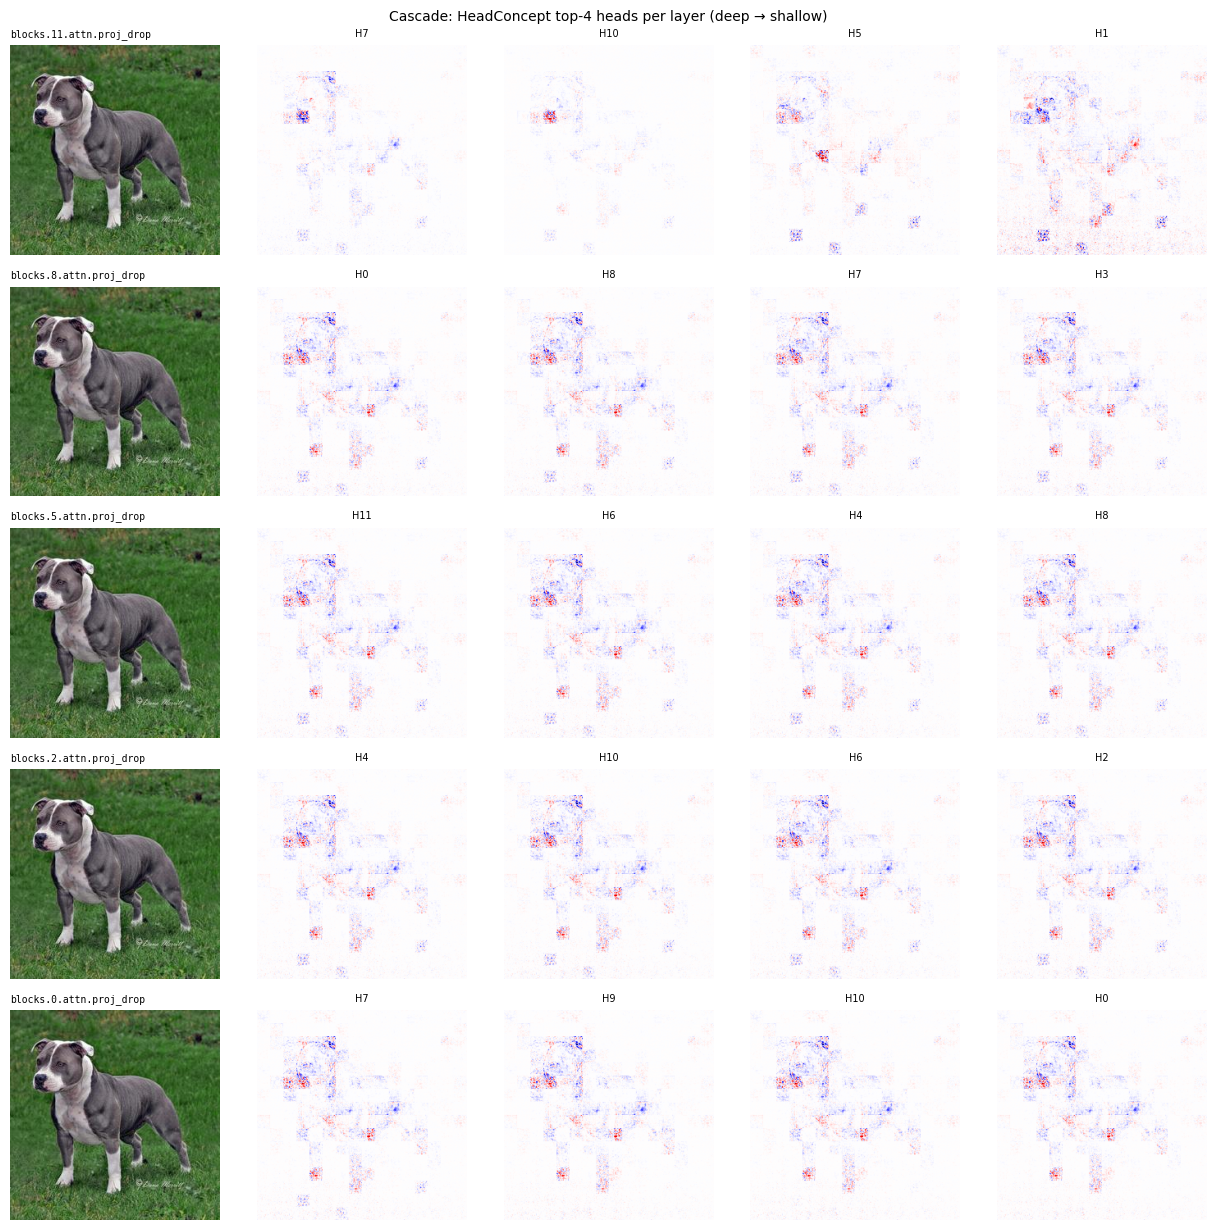

selected heads per layer (deep → shallow):
  backbone.blocks.11.attn.proj_drop  →  H[7, 10, 5, 1]
  backbone.blocks.8.attn.proj_drop  →  H[0, 8, 7, 3]
  backbone.blocks.5.attn.proj_drop  →  H[11, 6, 4, 8]
  backbone.blocks.2.attn.proj_drop  →  H[4, 10, 6, 2]
  backbone.blocks.0.attn.proj_drop  →  H[7, 9, 10, 0]


In [ ]:
import matplotlib.pyplot as plt

# Cascade depths: deep → shallow. Use proj_drop sites so we get the
# attention block's full output.
_L = _LAST_BLOCK
cascade_layer_names = [
    f'backbone.blocks.{i}.attn.proj_drop'
    for i in [_L, _L * 3 // 4, _L // 2, _L // 4, 0]
]

cascade_concept = HeadConcept(num_heads=NUM_HEADS)
TOP_K = 4

# Focal image (already picked above) → re-run forward + per-layer
# conditional attribution.
x_focal = normalize(focal_image).detach().clone().requires_grad_(True)

fig, axes = plt.subplots(
    len(cascade_layer_names), TOP_K + 1,
    figsize=(2.5 * (TOP_K + 1), 2.5 * len(cascade_layer_names)),
    squeeze=False,
)
extra_conditions = {}   # accumulates as we walk deep → shallow
selected = {}
for row, layer in enumerate(cascade_layer_names):
    # Per-head relevance scores under the cumulative conditioning.
    cond = {'y': [focal_class], **extra_conditions}
    res = attribution(
        x_focal, [cond], composite,
        mask_map=cascade_concept.mask, record_layer=[layer],
        exclude_parallel=False,
    )
    rel = res.relevances[layer]   # (1, N, embed_dim)
    head_scores = cascade_concept.attribute(rel, abs_norm=False)[0]   # (NUM_HEADS,)
    top_heads = torch.argsort(head_scores.abs(), descending=True)[:TOP_K].tolist()
    selected[layer] = top_heads

    # Show focal image on the left, then one heatmap per top head.
    axes[row, 0].imshow(focal_image[0].detach().cpu().permute(1, 2, 0).numpy()); axes[row, 0].axis('off')
    axes[row, 0].set_title(layer.replace('backbone.', ''), fontsize=7, loc='left', family='monospace')
    for col, h in enumerate(top_heads, start=1):
        x_h = normalize(focal_image).detach().clone().requires_grad_(True)
        res_h = attribution(
            x_h, [{layer: [h], 'y': [focal_class], **extra_conditions}],
            composite, mask_map=cascade_concept.mask,
            exclude_parallel=False,
        )
        heatmap = res_h.heatmap[0].detach().cpu().numpy()
        if heatmap.ndim == 3:
            heatmap = heatmap.sum(axis=0)
        vmax = abs(heatmap).max() or 1.0
        axes[row, col].imshow(heatmap, cmap='seismic', vmin=-vmax, vmax=vmax)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'H{h}', fontsize=7)

    # Add this layer's selection to extra_conditions for the next (shallower) layer.
    extra_conditions[layer] = top_heads

fig.suptitle(f'Cascade: HeadConcept top-{TOP_K} heads per layer (deep → shallow)', fontsize=10)
plt.tight_layout()
plt.show()

print('selected heads per layer (deep → shallow):')
for layer in cascade_layer_names:
    print(f'  {layer}  →  H{selected[layer]}')

## 8. Notes

* **One composite per paper.** Definitions + provenance in `zennit_extensions/lrp_composites/`; propagation equations transcribed in the experiment journal; registry `COMPOSITES` in the same package.
* **One concept, many sites.** Same `HeadConcept` / `EmbeddingDimConcept` instance hooks at `q/k/v_lrp_probe` or `proj_drop` — all `(B, N, embed_dim)`.
* **Token masking.** `token_filter=slice(NUM_PREFIX_TOKENS, None)` = spatial only; `slice(0, NUM_PREFIX_TOKENS)` = prefix only.
* **Skip the last block for prefix-token attribution.** The `dinov3_in1k` head reads the final-norm cls token only → register-token relevance at last-block `proj_drop` is exactly 0. Use an earlier block (section 5 indexes tokens mid-depth for this reason).
* **FV scope.** Section 4 subsamples ImageNet to a per-class pool for interactivity; drop the `subsample` call for the full 50k split (what the gallery indexes).
* **No `AttnWeightConcept`.** Softmax weights lack fixed per-neuron semantics → reference retrieval uninformative. Still hookable for raw attention maps: `record_layer=['backbone.blocks.{i}.attn.softmax']`.